# Итоговый отчёт по модели "Обедающие философы"

Данный скрипт выполняет сравнительный анализ двух моделей:
- Классическая сеть Петри (с deadlock)
- Сеть Петри с арбитром (без deadlock)

Сравнение проводится по количеству философов, находящихся в состоянии «Ест» (Eat_i).

## Подключение модулей

In [1]:
using DrWatson
@quickactivate "project"
using DataFrames, CSV, Plots

## Загрузка данных

Данные загружаются из CSV-файлов, созданных в ходе базового эксперимента:
- `dining_classic.csv` - результаты классической модели
- `dining_arbiter.csv` - результаты модели с арбитром

In [2]:
df_classic = CSV.read(datadir("dining_classic.csv"), DataFrame)
df_arbiter = CSV.read(datadir("dining_arbiter.csv"), DataFrame)

Row,time,Think_1,Think_2,Think_3,Think_4,Think_5,Hungry_1,Hungry_2,Hungry_3,Hungry_4,Hungry_5,Eat_1,Eat_2,Eat_3,Eat_4,Eat_5,Fork_1,Fork_2,Fork_3,Fork_4,Fork_5,Arbiter
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,4.0
2,0.0458546,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,3.0
3,0.197671,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0
4,0.265863,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
5,0.364923,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6,0.764979,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.28815,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
8,1.88528,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
9,2.10356,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0


## Параметры

`N` - количество философов (должно совпадать с параметром в базовом эксперименте)

In [3]:
N = 5

5

Столбцы для состояния "Ест"

In [4]:
eat_cols = [Symbol("Eat_$i") for i = 1:N]

5-element Vector{Symbol}:
 :Eat_1
 :Eat_2
 :Eat_3
 :Eat_4
 :Eat_5

## Построение графиков

### 1. Классическая сеть

На графике ожидается, что через некоторое время все линии Eat_i падают до нуля
и остаются на нуле — это и есть deadlock.

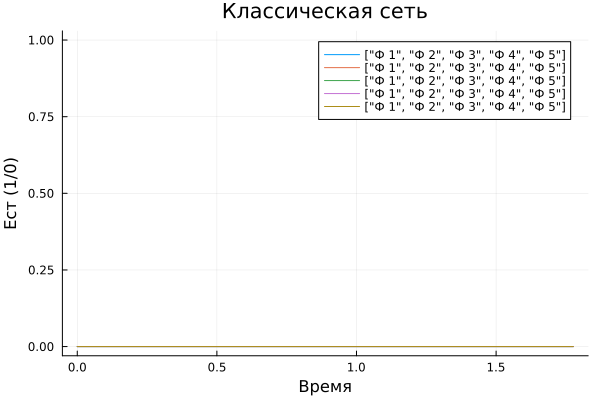

In [5]:
p1 = plot(
    df_classic.time,
    Matrix(df_classic[:, eat_cols]),
    label = ["Ф $i" for i = 1:N],
    xlabel = "Время",
    ylabel = "Ест (1/0)",
    title = "Классическая сеть",
)

### 2. Сеть с арбитром

На графике линии Eat_i должны колебаться, всегда есть хотя бы один философ,
который ест. Отсутствие длительных нулевых периодов подтверждает,
что система жива и не блокируется.

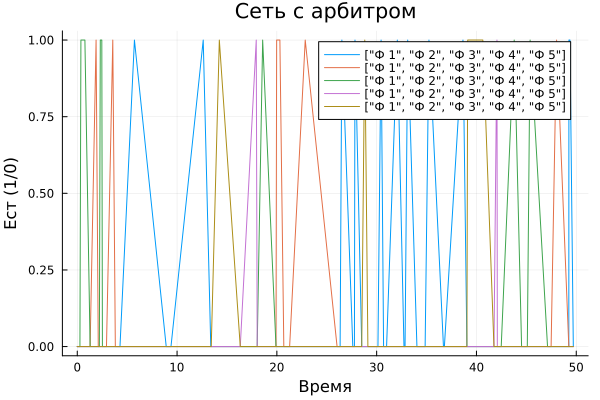

In [6]:
p2 = plot(
    df_arbiter.time,
    Matrix(df_arbiter[:, eat_cols]),
    label = ["Ф $i" for i = 1:N],
    xlabel = "Время",
    ylabel = "Ест (1/0)",
    title = "Сеть с арбитром",
)

## Объединение графиков

Два графика располагаются один над другим для удобства сравнения.

In [7]:
p_final = plot(p1, p2, layout = (2, 1), size = (800, 600))
savefig(plotsdir("final_report.png"))

"C:\\Users\\Александра\\work\\study\\2026-1\\2026-1==study--simulation-modeling\\labs\\lab05\\project\\plots\\final_report.png"

## Вывод

In [8]:
println("Отчёт сохранён в plots/final_report.png")

Отчёт сохранён в plots/final_report.png


### Интерпретация результатов

- **Классическая сеть**: на графике видно, что через некоторое время все линии
  Eat_i падают до нуля и остаются на нуле — это deadlock. Философы больше не могут есть.

- **Сеть с арбитром**: линии Eat_i колеблются, всегда есть хотя бы один философ,
  который ест (или они поочерёдно получают доступ). Отсутствие длительных нулевых
  периодов подтверждает, что система жива и не блокируется.

- График служит количественным доказательством эффективности арбитра.